# CBOW + Self-Attention Word2Vec -- Embedding Exploration

Loads the trained model from `models/checkpoint_step290000.pt` and:

1. t-SNE projection of word embeddings to 2D, plotted.
2. Nearest-neighbor queries for a handful of Darija words.
3. Runs `Embeddings/intrinsic_eval/scripts/evaluate_embeddings.py`'s word-similarity
   and analogy evaluation against this model.

Only the `input_embeddings` table is used as "the word vectors" -- the
self-attention/FFN block only ever processed *context windows* during
training (see `model.py`'s docstring: "only the input one is kept as 'the
word vectors' after training", standard word2vec convention). Run via the
GPU venv's kernel (CPU is fine here -- this notebook is just embedding
lookups + sklearn, no training).

In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE

import arabic_reshaper

ROOT = Path.cwd().resolve()
if ROOT.name == "word2vec":
    WORD2VEC_DIR = ROOT
    ROOT = ROOT.parents[1]
else:
    WORD2VEC_DIR = ROOT / "Embeddings" / "word2vec"

sys.path.insert(0, str(WORD2VEC_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
sys.path.insert(0, str(ROOT / "Embeddings" / "intrinsic_eval" / "scripts"))

from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

DATA_DIR = WORD2VEC_DIR / "data"
MODELS_DIR = WORD2VEC_DIR / "models"
CHECKPOINT = MODELS_DIR / "checkpoint_step290000.pt"

device = torch.device("cpu")  # embedding lookups only -- GPU not needed

# Arabic-safe label rendering. Tahoma/Arial must come before Segoe UI in the
# fallback list (Segoe UI doesn't render arabic_reshaper's presentation-form
# glyphs joined -- confirmed by a rendered comparison).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]

ARABIC_RE = re.compile(r"[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻿]")
LATIN_RE = re.compile(r"[a-zA-ZÀ-ɏ]")


def render_label(text: str) -> str:
    """Reshape Arabic-script text into joined presentation-form glyphs for
    correct matplotlib display. Deliberately does NOT also apply
    bidi.get_display() -- verified by a direct rendered A/B test against
    several known words ("خدمة", "السلام عليكم"): this environment's
    matplotlib/font stack already lays reshaped RTL glyphs out correctly on
    its own, so get_display's extra reversal on top produces a fully
    backwards word ("خدمة" -> "ةمدخ"). get_display is the textbook fix for
    renderers with NO bidi awareness at all -- this one isn't that case."""
    if ARABIC_RE.search(text):
        return arabic_reshaper.reshape(text)
    return text


def script_of(text: str) -> str:
    has_ar = bool(ARABIC_RE.search(text))
    has_lat = bool(LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


In [2]:
# Load the tokenizer, checkpoint metadata, and the model.
meta = json.loads((DATA_DIR / "meta.json").read_text(encoding="utf-8"))
token_freq = {int(k): v for k, v in json.loads((DATA_DIR / "token_freq.json").read_text(encoding="utf-8")).items()}
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]

ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]
print(f"Checkpoint: step={ckpt['step']:,}, epoch={ckpt.get('epoch', '?')}, args={ckpt_args}")

model = CBOWAttention(
    vocab_size=vocab_size,
    embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"],
    ff_dim=ckpt_args["ff_dim"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

embedding_matrix = model.input_embeddings.weight.detach().cpu().numpy()  # (vocab_size, embed_dim)
print("embedding_matrix shape:", embedding_matrix.shape)

PAD_ID = 0  # verified against Tokenization/models/bpe/bpe_20000/vocab.json

Checkpoint: step=290,000, epoch=9, args={'epochs': 10, 'target_pairs_per_batch': 4096, 'lr': 0.002, 'num_negative': 5, 'embed_dim': 128, 'num_heads': 4, 'ff_dim': 512, 'log_every': 200, 'checkpoint_every': 5000, 'resume': 'models\\checkpoint_step220000.pt'}
embedding_matrix shape: (20000, 128)


In [3]:
def get_word_vector(word: str) -> np.ndarray | None:
    """Word-level vector: BPE-encode the word, mean-pool the input embeddings
    of its piece(s). A single-token word (common for short/frequent Darija
    words) is just a direct table lookup; a multi-piece word is averaged --
    same convention used for OOV handling elsewhere in the repo's embedding
    eval tooling (evaluate_embeddings.py expects `str -> np.ndarray | None`).
    """
    ids = [i for i in tok.encode(word) if i != PAD_ID and i < vocab_size]
    if not ids:
        return None
    return embedding_matrix[ids].mean(axis=0)


# Sanity check
v = get_word_vector("\u0628\u0632\u0627\u0641")  # bezzaf ("a lot")
print("vector shape:", None if v is None else v.shape)

vector shape: (128,)


## 1. t-SNE projection to 2D

Two groups, plotted together but colored separately:
- **frequent corpus words** -- the top-N most common whitespace-split words
  in the training corpus (`rows.jsonl`'s cleaned `text`, not BPE pieces).
  Multi-token words get their vector from `get_word_vector` (mean of their
  BPE pieces' embeddings), same as any other word.
- **curated Darija words** -- every word appearing in the intrinsic-eval
  word-similarity/analogy sets.

In [4]:
EVAL_DATA_DIR = ROOT / "Embeddings" / "intrinsic_eval" / "data"


def load_curated_words() -> list[str]:
    words: set[str] = set()
    with (EVAL_DATA_DIR / "word_similarity.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            words.add(row["word1"])
            words.add(row["word2"])
    with (EVAL_DATA_DIR / "analogy_pairs.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            cat = json.loads(line)
            for p in cat["pairs"]:
                words.add(p["word_a"])
                words.add(p["word_b"])
    return sorted(words)


curated_words = load_curated_words()
print(f"{len(curated_words)} unique curated words")


def count_corpus_words() -> "Counter[str]":
    """Word-level frequency count over the full corpus, splitting on
    whitespace (not BPE tokenization) -- per-word vectors already average
    BPE-piece embeddings via get_word_vector, so what's needed here is real
    corpus WORDS, matching how a person would split the text, not subword
    pieces."""
    from collections import Counter

    counts: Counter[str] = Counter()
    with (DATA_DIR / "rows.jsonl").open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            counts.update(json.loads(line)["text"].split())
            if (i + 1) % 1_000_000 == 0:
                print(f"  ...{i + 1:,} rows scanned")
    return counts


word_freq = count_corpus_words()
print(f"{len(word_freq):,} unique words across {sum(word_freq.values()):,} whitespace-split tokens")

TOP_N_FREQUENT_WORDS = 150
# Placeholders like [URL]/[MENTION] (see clean_text.py) and pure-digit/punctuation
# "words" aren't real vocabulary -- script_of() (arabic/latin) filters them out.
frequent_words = [
    w for w, _ in word_freq.most_common(TOP_N_FREQUENT_WORDS * 3)
    if script_of(w) in ("arabic", "latin", "mixed")
][:TOP_N_FREQUENT_WORDS]
print(f"{len(frequent_words)} frequent corpus words")

463 unique curated words


  ...1,000,000 rows scanned


  ...2,000,000 rows scanned


  ...3,000,000 rows scanned


  ...4,000,000 rows scanned


  ...5,000,000 rows scanned


3,906,731 unique words across 84,251,500 whitespace-split tokens


150 frequent corpus words


In [5]:
frequent_words_set = set(frequent_words)
curated_words_deduped = [w for w in curated_words if w not in frequent_words_set]

plot_vectors = []
plot_labels = []
plot_groups = []  # "frequent" or "curated"

for w in frequent_words:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("frequent")

for w in curated_words_deduped:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("curated")

X = np.stack(plot_vectors)
print(f"t-SNE input: {X.shape[0]} points, {X.shape[1]} dims")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords = tsne.fit_transform(X)

t-SNE input: 579 points, 128 dims


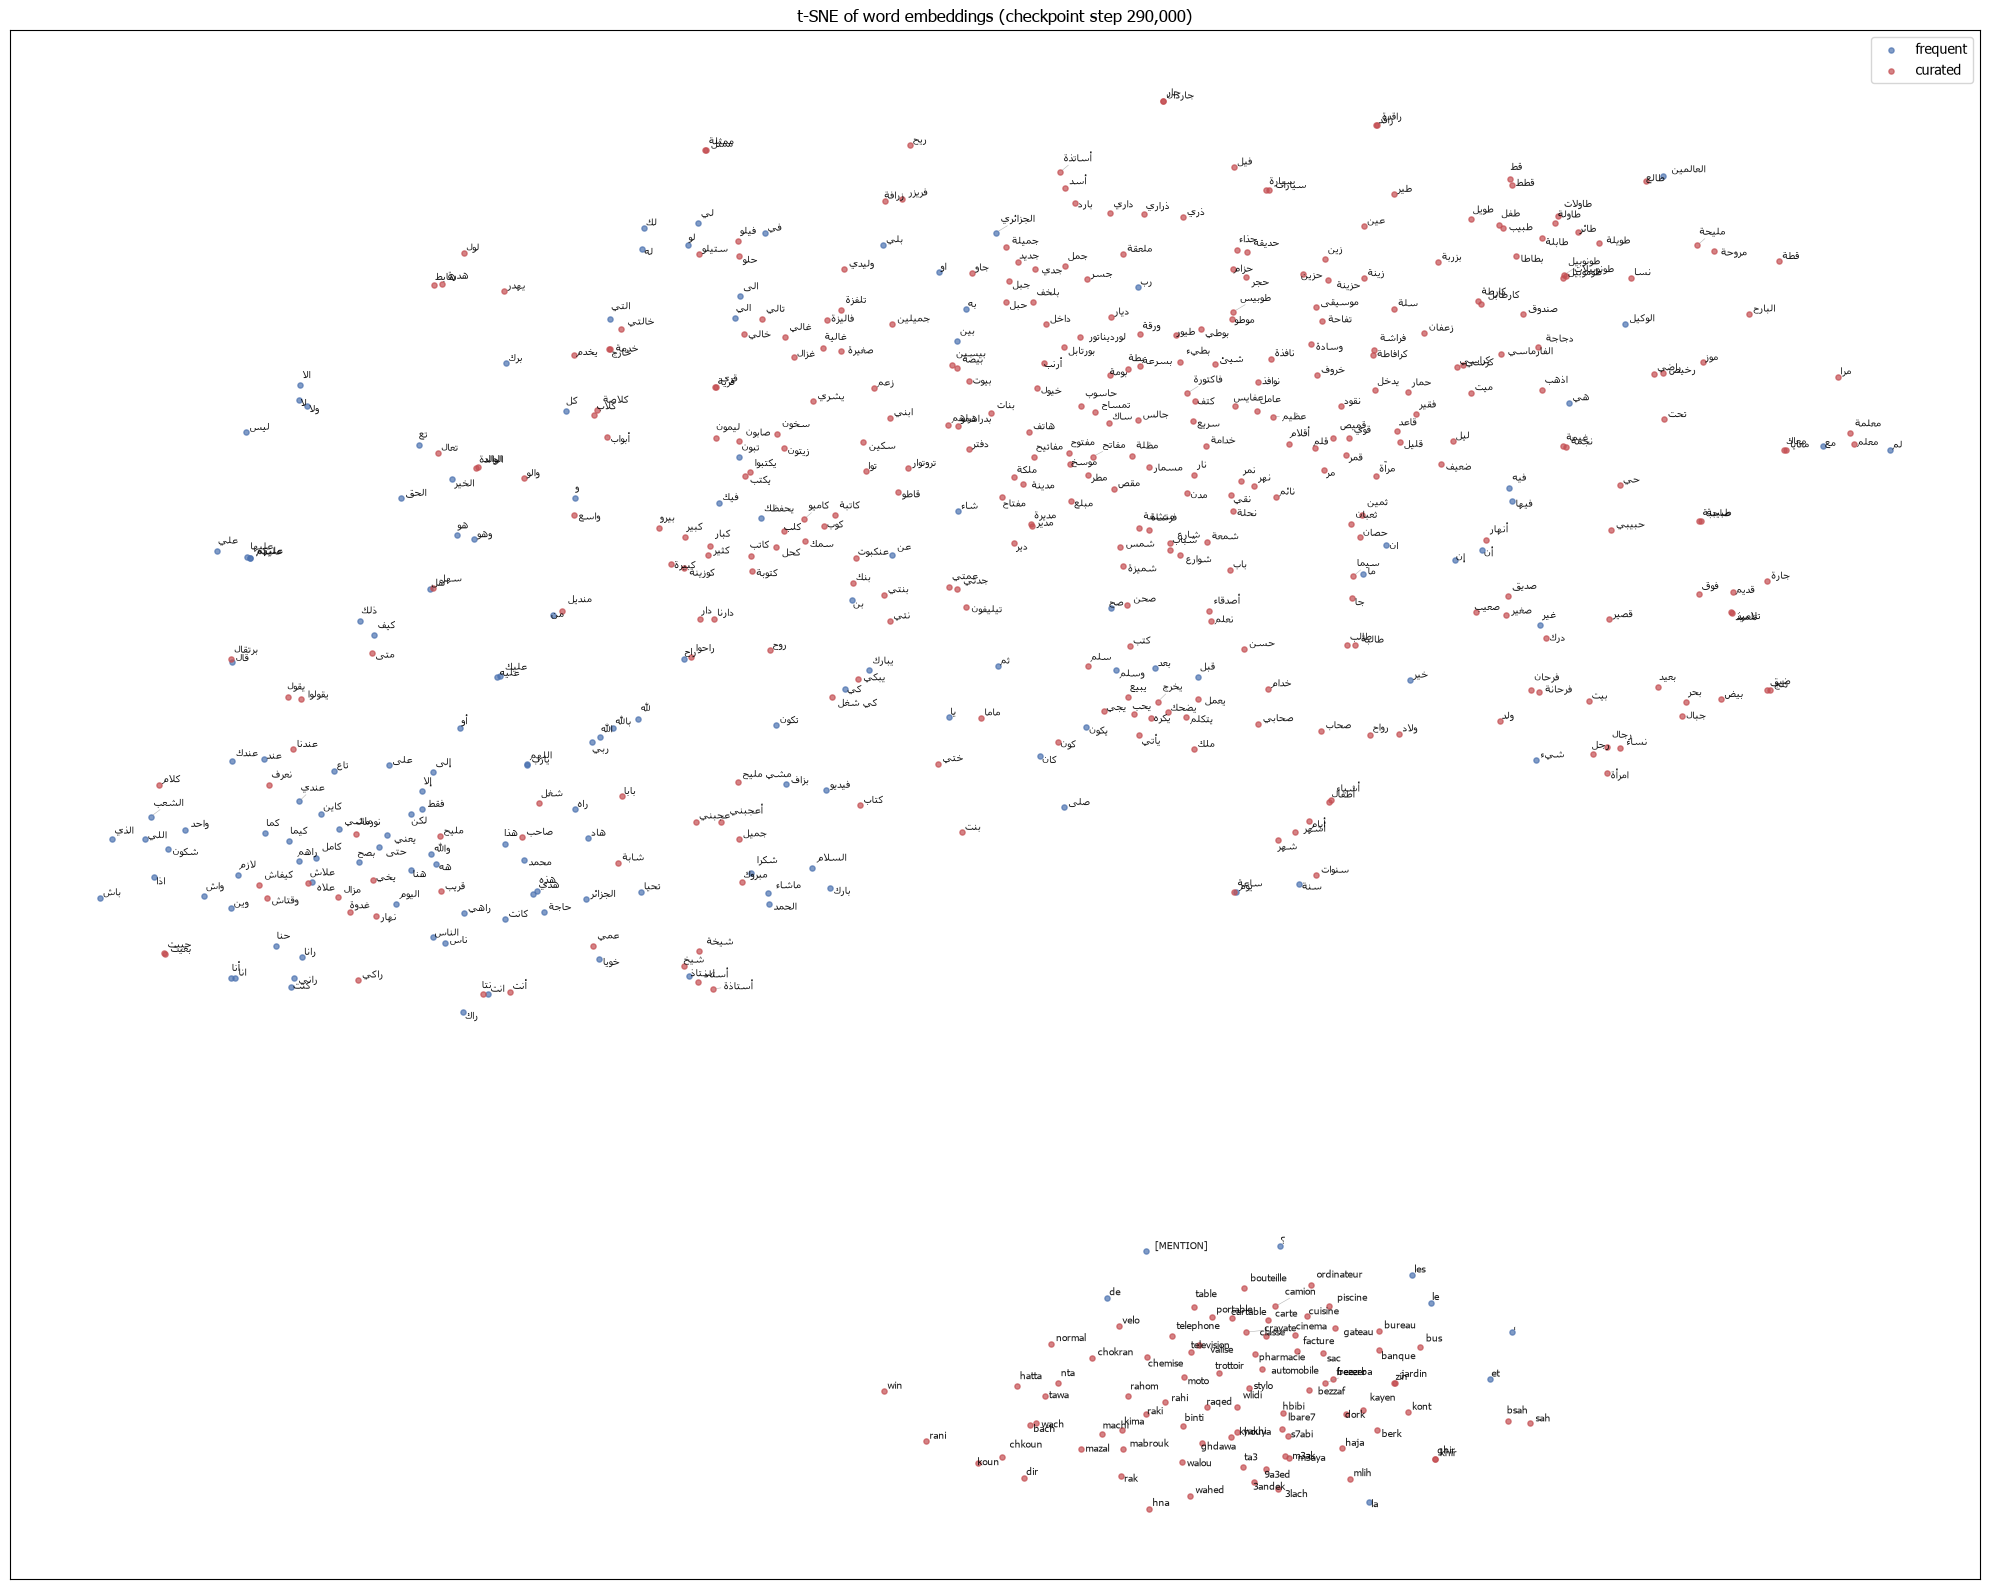

In [6]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(20, 16))

colors = {"frequent": "#4C72B0", "curated": "#C44E52"}
for group in ("frequent", "curated"):
    idx = [i for i, g in enumerate(plot_groups) if g == group]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=14, color=colors[group], alpha=0.7, label=group)

# With ~600 points crammed into 2D, plain fixed-offset labels overlap and
# adjacent words visually merge into unreadable garbage (e.g. two labels
# sitting flush against each other read as one long fake "word"). adjustText
# repels overlapping labels apart and draws a thin line back to the true
# point, which plain annotate() offsets can't do.
texts = [
    ax.text(coords[i, 0], coords[i, 1], render_label(label), fontsize=7, alpha=0.9)
    for i, label in enumerate(plot_labels)
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.6))

ax.set_title("t-SNE of word embeddings (checkpoint step 290,000)")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Nearest neighbors

Candidate pool = curated words ∪ frequent corpus words (the same points
plotted above, all real space-split words -- see `get_word_vector`),
ranked by cosine similarity to the query word's vector.

In [7]:
pool_matrix = X  # reuse the same vectors gathered for the t-SNE plot
pool_words = plot_labels
pool_norms = np.linalg.norm(pool_matrix, axis=1, keepdims=True)
pool_normed = pool_matrix / np.clip(pool_norms, 1e-9, None)


def nearest_neighbors(word: str, k: int = 10) -> list[tuple[str, float]]:
    qv = get_word_vector(word)
    if qv is None:
        return []
    qv = qv / max(np.linalg.norm(qv), 1e-9)
    sims = pool_normed @ qv
    order = np.argsort(-sims)
    results: list[tuple[str, float]] = []
    for i in order:
        w = pool_words[i]
        if w == word:
            continue
        results.append((w, float(sims[i])))
        if len(results) >= k:
            break
    return results


demo_words = ["\u0628\u0632\u0627\u0641", "\u062e\u062f\u0645\u0629", "\u0648\u0627\u0634", "\u062d\u0628\u064a\u0628\u064a", "\u0645\u0644\u064a\u062d", "\u0648\u0644\u062f", "\u0628\u0646\u062a", "\u0632\u064a\u0646"]
# bezzaf, khedma, wach, hbibi, mlih, wled, bnt, zin

for w in demo_words:
    neighbors = nearest_neighbors(w, k=10)
    print(f"\n{w}:")
    for nw, score in neighbors:
        print(f"  {score:.3f}  {nw}")


بزاف:
  0.559  ماشي
  0.556  فيديو
  0.528  كامل
  0.522  حاجة
  0.520  مليح
  0.516  مشي مليح
  0.491  شابة
  0.483  بصح
  0.477  كاين
  0.465  راهم

خدمة:
  0.794  خارج
  0.619  يخدم
  0.614  خالتي
  0.556  خالي
  0.547  حزينة
  0.537  بزربة
  0.506  صديق
  0.473  بطاطا
  0.456  بسرعة
  0.452  طبيب

واش:
  0.642  كيفاش
  0.608  شكون
  0.596  وين
  0.588  علاش
  0.587  علاه
  0.563  كيما
  0.556  يخي
  0.547  حبيت
  0.537  وقتاش
  0.527  نتا

حبيبي:
  0.516  بيوت
  0.501  يبكي
  0.500  بيضة
  0.475  طبيبة
  0.466  صاحبة
  0.460  كي
  0.457  يحب
  0.437  حي
  0.431  صعيب
  0.425  صديق

مليح:
  0.639  ماشي
  0.638  بصح
  0.637  يعني
  0.634  لازم
  0.621  نورمال
  0.600  علاش
  0.592  كامل
  0.591  حتى
  0.588  مشي مليح
  0.588  علاه

ولد:
  0.629  ولاد
  0.625  رجل
  0.574  بحر
  0.572  بيض
  0.554  ضيق
  0.527  بيت
  0.523  رجال
  0.518  فرحانة
  0.508  قصير
  0.487  غير

بنت:
  0.537  ولاد
  0.525  هذي
  0.497  كانت
  0.491  بن
  0.483  تحيا
  0.481  ولد
  0.466  نعرف
  0.454  هذه
 

## 3. Intrinsic evaluation (`evaluate_embeddings.py`)

Same word-similarity (Spearman correlation) and analogy (vector-arithmetic
nearest-neighbor) evaluation used by `Embeddings/intrinsic_eval`, wired to
this trained model's `get_word_vector`.

In [8]:
from evaluate_embeddings import evaluate_similarity, evaluate_analogies

print("=== Word similarity (Spearman correlation) ===")
sim = evaluate_similarity(get_word_vector)
print(
    f"Overall: r={sim['overall_spearman']:.4f} (p={sim['overall_p_value']:.4f}), "
    f"n={sim['n_pairs_scored']}, oov={sim['n_pairs_oov']}"
)
for cat, r in sim["by_category"].items():
    print(f"  {cat:<24} r={r['spearman']:.4f}  n={r['n_pairs']}  oov={r['n_oov']}")

print("\n=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===")
ana = evaluate_analogies(get_word_vector)
print(f"Overall: acc={ana['overall_accuracy']:.4f}, n={ana['overall_n_questions']}")
for cat, r in ana["by_category"].items():
    print(f"  {cat:<24} acc={r['accuracy']:.4f}  n={r['n_questions']}  skipped_oov={r['n_skipped_oov']}")

=== Word similarity (Spearman correlation) ===
Overall: r=-0.2805 (p=0.0000), n=215, oov=0
  synonym                  r=0.4589  n=31  oov=0
  antonym                  r=-0.0393  n=29  oov=0
  cross_script             r=0.3915  n=49  oov=0
  code_switch              r=0.0058  n=30  oov=0
  morphological_variant    r=-0.2466  n=36  oov=0
  unrelated                r=0.1399  n=40  oov=0

=== Analogies (vector-arithmetic nearest-neighbor accuracy) ===


Overall: acc=0.1883, n=4290
  gender                   acc=0.3391  n=870  skipped_oov=0
  singular_plural          acc=0.3207  n=870  skipped_oov=0
  script_transliteration   acc=0.0918  n=2550  skipped_oov=0
